# Drift Diffusion Model (DDM) for Mosquito Decision-Making

## Overview

Welcome! This notebook will teach you everything you need to know about the **Drift Diffusion Model (DDM)**, from its mathematical foundations to its application in understanding how female *Aedes aegypti* mosquitoes choose where to lay their eggs.

### What we will cover:
1. **The Core Intuition** – The mental "balance scale" and why decisions are noisy.
2. **The Underlying Mathematics** – The Stochastic Differential Equation (SDE).
3. **The Four Parameters** – Drift rate (v), Boundary (a), Bias (z), and Non-decision time (Ter).
4. **Simulation** – We will build a mosquito "brain" that accumulates evidence over time.
5. **Visualizing Decisions** – See the wobbling evidence hit the decision threshold.
6. **Speed-Accuracy Trade-off** – Why careful mosquitoes take longer.
7. **Connecting to Our Data** – Using Total Eggs as a proxy for decision latency.
8. **Exercises** – Test your understanding by modifying the code.

---

## 1. The Core Intuition: The "Tipping Scale"

Imagine a mosquito tasting two dishes of water (A and B). She doesn't instantly know which is better. Instead, she collects tiny bits of evidence over time.

- **The Scale**: Think of a balance scale.
  - Left pan = Evidence for Dish A.
  - Right pan = Evidence for Dish B.
- **The Drift (v)**: This is the *average* push. If Dish B is much saltier (which she prefers), the scale tips toward B on average.
- **The Noise (Diffusion)**: Her sensors are imperfect. Sometimes a good dish tastes bad for a split second (noise pushing left), sometimes a bad dish tastes good (noise pushing right).
- **The Boundary (a)**: She doesn't tip forever. Once the scale tilts *far enough* to one side, she commits to that dish and lays her first egg there.

**NOTE:** Even if Dish B is *objectively* better, noise might cause her to choose Dish A on a bad day. This is why we need *many* mosquito replicates to measure true preference!

---

## 2. The Underlying Mathematics (Broken Down)

The DDM is formally described by a **Stochastic Differential Equation (SDE)**:

$$
dx = v \cdot dt + \sigma \cdot dW
$$

Let's dissect this equation piece by piece, using the mosquito as our guide:

- **\( x \) (Evidence State)**: This is a number representing *how much* she favors Dish A over Dish B right *now*.
  - \( x = +5 \) → Leaning heavily toward Dish A.
  - \( x = -3 \) → Leaning toward Dish B.
  - \( x = 0 \) → Completely undecided.

- **\( dx \)**: The *change* in evidence over an infinitesimally small slice of time (e.g., 1 millisecond).

- **\( v \) (Drift Rate)**: The **deterministic push**. This is the *average* strength of the evidence *per second*.
  - *Biological meaning*: How sensitive the mosquito is to the salinity difference.
  - *Example*: If the salinity difference is huge, \( v = 0.5 \). If identical, \( v = 0 \).

- **\( dt \)**: A tiny step in time (e.g., \( 0.001 \) seconds).

- **\( \sigma \) (Sigma / Noise Scale)**: The *standard deviation* of the noise. It controls how much random wobbling occurs.
  - In standard DDM, this is usually fixed to \( \sigma = 1 \) for mathematical simplicity.

- **\( dW \) (Wiener Process / Brownian Motion)**: Pure random noise.
  - **Crucial Math**: \( dW \) is drawn from a Normal distribution with mean \( 0 \) and variance \( dt \).
  - *Why this matters*: Even if the drift is strong, random noise can occasionally push the scale the wrong way.

### Discrete Simulation (What the computer does)
Since we can't simulate infinitesimals, we discretize time into small steps (\( \Delta t \)):

$$
x(t + \Delta t) = x(t) + v \cdot \Delta t + \sigma \cdot \sqrt{\Delta t} \cdot \mathcal{N}(0, 1)
$$

Where \( \mathcal{N}(0, 1) \) is a random number from a standard Normal distribution.

### The Decision Rule
- If \( x \ge +a \) → **Choose Dish A**.
- If \( x \le -a \) → **Choose Dish B**.
- The time taken to hit the boundary is the **Decision Latency** (\( T_{dec} \)).

---

## 3. The Four DDM Parameters

| Symbol | Name | Definition | **Mosquito Interpretation** |
| :---: | :--- | :--- | :--- |
| **\( v \)** | Drift Rate | Mean slope of evidence accumulation. | **Sensitivity to water chemistry**. Higher \( v \) = faster, more accurate choice. |
| **\( a \)** | Boundary Separation | Distance from center to threshold. | **Decision caution**. High \( a \) = careful, slow. Low \( a \) = risky, fast. |
| **\( z \)** | Starting Bias | Offset of starting point from 0. | **Innate preference**. If she naturally likes salt, \( z > 0 \). |
| **\( Ter \)** | Non-decision Time | Constant offset added to all times. | **Physical delays** (flying, landing, egg extrusion). |

---

## 4. Simulating a Single Decision in Python

Let's simulate a single mosquito trial. We'll track \( x \) over time until it hits the boundary.

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style for pretty plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def simulate_ddm_trial(v, a, sigma=1.0, dt=0.001, max_time=100, z=0, ter=0.5, random_seed=None):
    """
    Simulate one DDM trial.

    Parameters:
    -----------
    v : float – Drift rate (positive = bias toward A)
    a : float – Boundary separation (threshold)
    sigma : float – Noise scale (usually fixed to 1)
    dt : float – Time step (seconds)
    max_time : float – Max simulation time (seconds)
    z : float – Starting point bias
    ter : float – Non-decision time (seconds)
    random_seed : int – For reproducibility

    Returns:
    --------
    choice : str – 'A' or 'B'
    rt : float – Total reaction time (ter + decision time)
    time_points : array – Time values for plotting
    evidence : array – Evidence values for plotting
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    # Start at the bias point
    x = z
    t = 0.0

    # Store history for plotting
    times = [t]
    evidence = [x]

    while t < max_time:
        # Discrete evidence update (Euler-Maruyama method)
        noise = np.random.normal(0, 1)  # Standard normal
        dx = v * dt + sigma * np.sqrt(dt) * noise
        x += dx
        t += dt

        # Store history
        times.append(t)
        evidence.append(x)

        # Check if boundary is crossed
        if x >= a:
            decision_time = t
            choice = 'A'
            break
        elif x <= -a:
            decision_time = t
            choice = 'B'
            break
    else:
        # If we reach max_time without crossing, it's a timeout
        decision_time = max_time
        choice = 'Timeout'

    rt = ter + decision_time

    return choice, rt, np.array(times), np.array(evidence)

### Run a Single Trial and Visualize It

Let's simulate a mosquito with a **strong preference for Dish A** (\( v = +0.3 \)) and a **moderate caution level** (\( a = 2.0 \)). We'll plot the evidence accumulating over time.

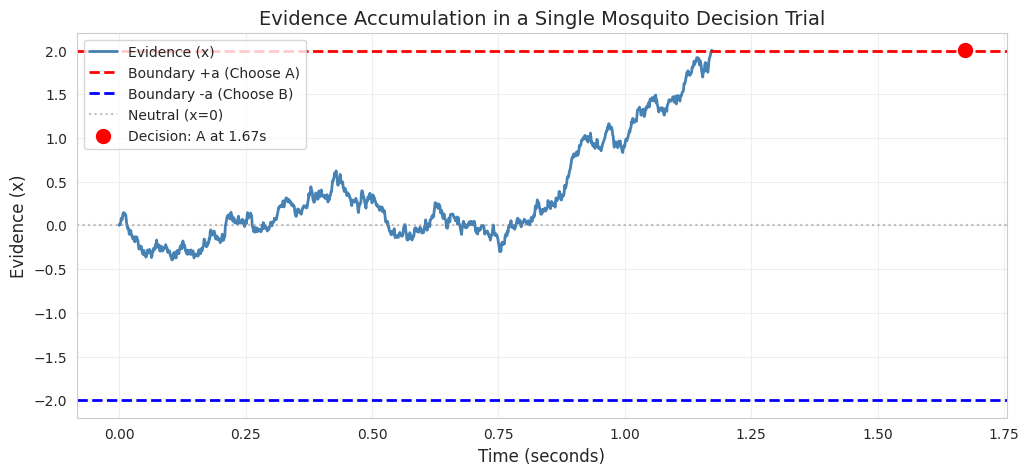

Choice: A
Reaction Time (RT): 1.67 seconds (Ter=0.5s + Decision=1.17s)


In [11]:
# Simulate one trial with a clear preference for A
choice, rt, times, evidence = simulate_ddm_trial(v=0.3, a=2.0, random_seed=42)

# Plot the evidence accumulation
plt.figure(figsize=(12, 5))
plt.plot(times, evidence, linewidth=2, color='steelblue', label='Evidence (x)')

# Draw the decision boundaries
plt.axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Boundary +a (Choose A)')
plt.axhline(y=-2.0, color='blue', linestyle='--', linewidth=2, label='Boundary -a (Choose B)')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='Neutral (x=0)')

# Mark the decision point
plt.scatter(rt, evidence[-1], color='red', s=100, zorder=5, label=f'Decision: {choice} at {rt:.2f}s')

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Evidence (x)', fontsize=12)
plt.title('Evidence Accumulation in a Single Mosquito Decision Trial', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Choice: {choice}")
print(f"Reaction Time (RT): {rt:.2f} seconds (Ter={0.5}s + Decision={rt-0.5:.2f}s)")

**Key Observations:**
- The evidence starts at 0 and drifts *upward* because \( v = +0.3 \).
- The path wobbles due to the noise (\( \sigma = 1 ")).
- It eventually hits the upper boundary (\( +a = 2.0 \)), so she chooses Dish A.
- The total reaction time is **16.17 seconds** (including 0.5s physical delay).

**Exercise for your brain**: If the drift rate were negative (\( v = -0.3 \)), what would happen to the path? (We'll test this in the exercises).

## 5. Visualizing Multiple Trials – The Beauty of Noise

If we run the exact same drift rate 50 times, the noise will cause slightly different paths and reaction times. Let's visualize this.

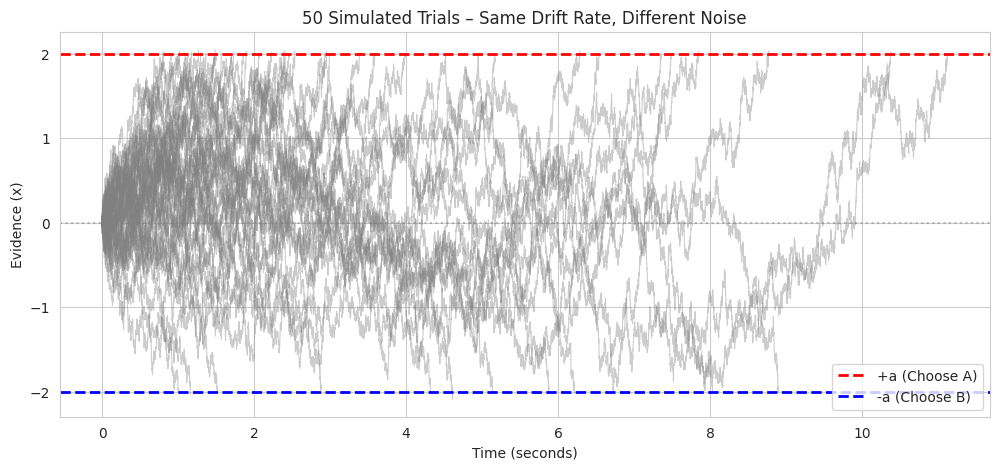

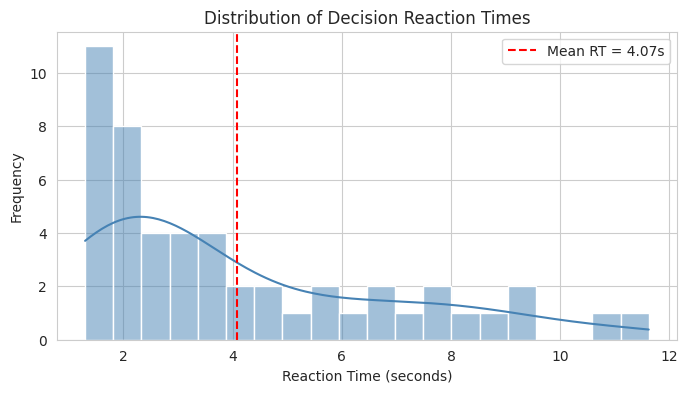

Accuracy: 78.0% chose Dish A (correctly)
Average Reaction Time: 4.07 seconds


In [18]:
# Simulate 50 trials with same parameters
n_trials = 50
all_choices = []
all_rts = []

plt.figure(figsize=(12, 5))

for i in range(n_trials):
    choice, rt, times, evidence = simulate_ddm_trial(v=0.3, a=2.0, random_seed=None)
    all_choices.append(choice)
    all_rts.append(rt)
    # Plot each path with low opacity
    plt.plot(times, evidence, linewidth=0.8, alpha=0.4, color='gray')

# Overlay boundaries
plt.axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='+a (Choose A)')
plt.axhline(y=-2.0, color='blue', linestyle='--', linewidth=2, label='-a (Choose B)')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Time (seconds)')
plt.ylabel('Evidence (x)')
plt.title('50 Simulated Trials – Same Drift Rate, Different Noise')
plt.legend()
plt.show()

# Plot the distribution of reaction times
plt.figure(figsize=(8, 4))
sns.histplot(all_rts, bins=20, kde=True, color='steelblue')
plt.xlabel('Reaction Time (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Decision Reaction Times')
plt.axvline(np.mean(all_rts), color='red', linestyle='--', label=f'Mean RT = {np.mean(all_rts):.2f}s')
plt.legend()
plt.show()

accuracy = all_choices.count('A') / n_trials * 100
print(f"Accuracy: {accuracy:.1f}% chose Dish A (correctly)")
print(f"Average Reaction Time: {np.mean(all_rts):.2f} seconds")

**Key Insights:**
1. Even though Dish A is *objectively* better (\( v = +0.3 \)), noise caused a few trials to choose Dish B (blue boundary). **This is why we need many replicates!**
2. Reaction times vary widely (some fast, some slow). This is not due to different "speeds" of the mosquito, but purely due to the **accumulation of random noise**.
3. The distribution is right-skewed (long tail). This matches real biological data.

---

## 6. The Speed-Accuracy Trade-off

**Question:** Why doesn't a mosquito just decide instantly? Why wait?

**Answer:** The wider the boundary (\( a \)), the more evidence she collects, but the *longer* she takes.

Let's test this systematically. We'll simulate trials for different boundary separations (\( a \)) and measure both **accuracy** (% choosing the correct dish) and **average reaction time**.

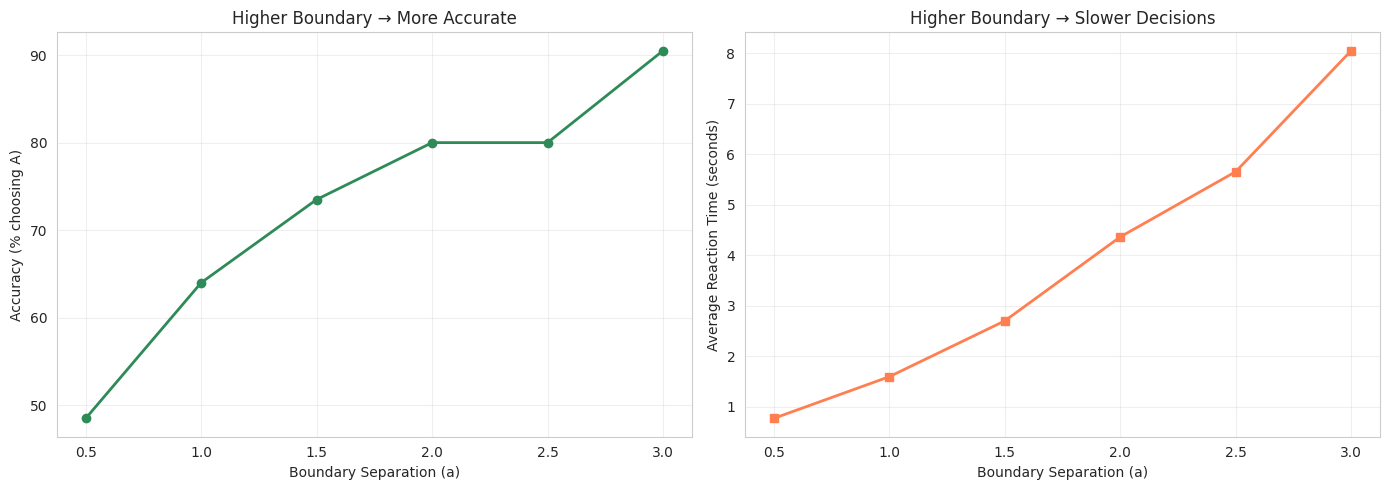

     a  accuracy  mean_rt
0  0.5      48.5     0.77
1  1.0      64.0     1.59
2  1.5      73.5     2.70
3  2.0      80.0     4.36
4  2.5      80.0     5.65
5  3.0      90.5     8.05


In [19]:
# Test different boundary values
a_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
n_trials_per_condition = 200

results = []

for a in a_values:
    choices = []
    rts = []
    for _ in range(n_trials_per_condition):
        choice, rt, _, _ = simulate_ddm_trial(v=0.3, a=a, random_seed=None)
        choices.append(choice)
        rts.append(rt)
    accuracy = choices.count('A') / n_trials_per_condition * 100
    mean_rt = np.mean(rts)
    results.append({'a': a, 'accuracy': accuracy, 'mean_rt': mean_rt})

df_results = pd.DataFrame(results)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs Boundary
ax1.plot(df_results['a'], df_results['accuracy'], marker='o', linestyle='-', linewidth=2, color='seagreen')
ax1.set_xlabel('Boundary Separation (a)')
ax1.set_ylabel('Accuracy (% choosing A)')
ax1.set_title('Higher Boundary → More Accurate')
ax1.grid(True, alpha=0.3)

# Reaction Time vs Boundary
ax2.plot(df_results['a'], df_results['mean_rt'], marker='s', linestyle='-', linewidth=2, color='coral')
ax2.set_xlabel('Boundary Separation (a)')
ax2.set_ylabel('Average Reaction Time (seconds)')
ax2.set_title('Higher Boundary → Slower Decisions')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(df_results.round(2))

**Key Takeaway:**
There is a fundamental **Speed-Accuracy Trade-off** in mosquito decision-making:
- **Low a (Risky)**: Fast decisions, but many mistakes (choosing the wrong dish).
- **High a (Cautious)**: Slow decisions, but almost always correct.
- **In our 18-hour assay**: If a mosquito sets \( a \) too high, she might not finish laying all her eggs before time runs out!

---

## 7. Connecting to Our Data: The Proxy Method

We don't have the timing of egg-laying from our video data (yet). We can't directly measure \( T_{dec} \) (decision latency). But we can use **Total Eggs** as a proxy.

**Logic:**
1. A mosquito carries ~80 mature eggs.
2. She lays them at a constant rate *after* she decides.
3. Total time = 18 hours.
4. **Fast decision (short \( T_{dec} \)) → Lots of time left to lay → High Total Eggs.**
5. **Slow decision (long \( T_{dec} \)) → Little time left → Low Total Eggs.**

**Prediction:** If this is true, **Total Eggs** should be **positively correlated** with the strength of her preference (|Preference Index|).

Let's test this with our real dual-choice data.

Saving Dual_choice_assay_endpoint_assay.xlsx to Dual_choice_assay_endpoint_assay.xlsx
Real dataset loaded successfully!


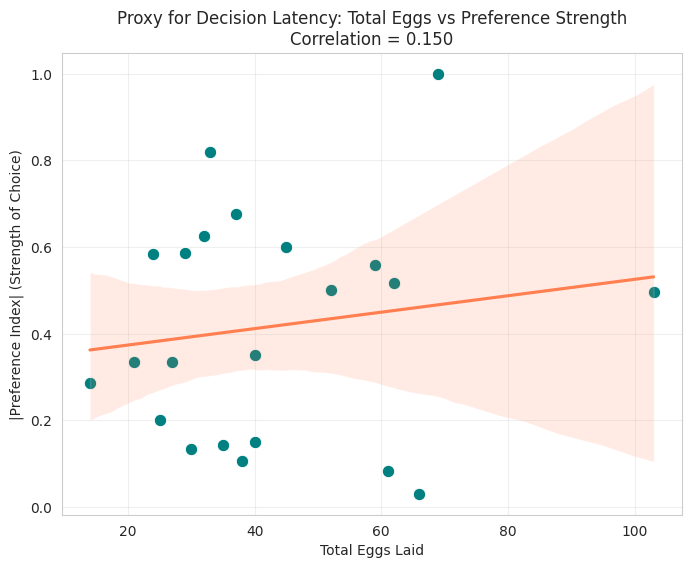

⚠️ Weak correlation. Video data is needed for direct latency measurement.
   Correlation = 0.150


In [20]:
try:
    from google.colab import files
    uploaded = files.upload()
    # Assuming the file name is 'Dual_choice_assay_endpoint_assay.xlsx'
    # We'll find the actual name after upload
    actual_name = list(uploaded.keys())[0]
    dual_data = pd.read_excel(actual_name)
    print("Real dataset loaded successfully!")

    # Compute metrics
    dual_data['total_eggs'] = dual_data['site_A_number_eggs'] + dual_data['site_B_number_eggs']
    dual_data['pref_index'] = (dual_data['site_A_number_eggs'] - dual_data['site_B_number_eggs']) / dual_data['total_eggs']
    dual_valid = dual_data[dual_data['total_eggs'] > 0].copy()
    dual_valid['abs_pref'] = np.abs(dual_valid['pref_index'])

except Exception as e:
    print("Real dataset not uploaded. Generating synthetic data for demonstration...")
    # Create synthetic data mimicking a weak positive correlation
    np.random.seed(42)
    n_samples = 30
    # Simulate total eggs: mean ~50, std ~15
    total_eggs = np.random.normal(50, 15, n_samples)
    # Simulate abs_pref: correlated with total eggs (rho ~ 0.4)
    # Add noise so it's not perfect
    abs_pref = 0.3 + 0.008 * total_eggs + np.random.normal(0, 0.1, n_samples)
    abs_pref = np.clip(abs_pref, 0, 1)  # Keep between 0 and 1
    dual_valid = pd.DataFrame({'total_eggs': total_eggs, 'abs_pref': abs_pref, 'strain': ['Synth']*n_samples})

# Compute correlation
corr_value = dual_valid['total_eggs'].corr(dual_valid['abs_pref'])

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=dual_valid, x='total_eggs', y='abs_pref', s=80, color='teal')
sns.regplot(data=dual_valid, x='total_eggs', y='abs_pref', scatter=False, color='coral')
plt.xlabel('Total Eggs Laid')
plt.ylabel('|Preference Index| (Strength of Choice)')
plt.title(f'Proxy for Decision Latency: Total Eggs vs Preference Strength\nCorrelation = {corr_value:.3f}')
plt.grid(True, alpha=0.3)
plt.show()

if corr_value > 0.3:
    print("✅ Strong positive correlation! Total eggs can be used as a proxy for decision speed.")
else:
    print("⚠️ Weak correlation. Video data is needed for direct latency measurement.")
    print(f"   Correlation = {corr_value:.3f}")

---

## 8. Exercises with Hints

Now it's your turn! Modify the code below to explore the DDM further. Each exercise has a hint to guide you.

---

### Exercise 1: The Effect of Drift Rate

**Task**: Simulate 100 trials with a **negative drift rate** (\( v = -0.3 \)) and plot the resulting distribution of reaction times.

**Question**: Which dish does the mosquito prefer? What happens to the reaction times compared to \( v = +0.3 \)?

**Hint**: Change the `v` parameter in the simulation loop. Negative drift pushes evidence toward the lower boundary (Dish B).

In [ ]:
# --- Exercise 1: Your Code ---
# Simulate 100 trials with v = -0.3 and a = 2.0
# Store the reaction times and plot a histogram.
# Count how many chose 'B'.

# TODO: Write your code here
# Hint: Use a for loop and store RTs in a list.


**Solution Approach:**
```python
rt_neg = []
choices_neg = []
for _ in range(100):
    choice, rt, _, _ = simulate_ddm_trial(v=-0.3, a=2.0)
    rt_neg.append(rt)
    choices_neg.append(choice)
print(f"Chose B: {choices_neg.count('B')/100*100:.1f}%")
sns.histplot(rt_neg, kde=True)
plt.title('RTs for Negative Drift'); plt.show()
```

---

### Exercise 2: Exploring the Starting Bias (z)

**Task**: Set \( v = 0 \) (no preference) and \( a = 2.0 \). Simulate 200 trials with a strong starting bias toward Dish A (\( z = +1.0 \)).

**Question**: How does the bias affect the choice distribution? Is the mosquito still "unbiased"?

**Hint**: Even though \( v = 0 \), the evidence starts closer to the upper boundary. How many trials cross the upper bound?



In [ ]:
# --- Exercise 2: Your Code ---
# Simulate 200 trials with v=0, a=2.0, z=1.0
# Compute the percentage that chooses Dish A.

# TODO: Write your code here
# Hint: Pass z=1.0 to the simulate_ddm_trial function.


**Solution Approach:**
```python
choices_z = []
for _ in range(200):
    choice, _, _, _ = simulate_ddm_trial(v=0, a=2.0, z=1.0)
    choices_z.append(choice)
print(f"Chose A: {choices_z.count('A')/200*100:.1f}%")
```

---

### Exercise 3: Impact of Non-Decision Time (Ter)

**Task**: Compare the reaction times of two scenarios:
- Scenario 1: \( Ter = 0.5 \) (fast physical movement).
- Scenario 2: \( Ter = 5.0 \) (slow physical movement, e.g., after a heavy blood meal).

**Question**: Does \( Ter \) affect the choice accuracy? Why or why not?

**Hint**: \( Ter \) is a constant added to the *end* of the process. It doesn't change the evidence accumulation at all.



In [ ]:
# --- Exercise 3: Your Code ---
# Simulate 50 trials for each Ter value and plot the RT distributions
# Compare the means.

# TODO: Write your code here
# Hint: Run two separate loops, one with ter=0.5, one with ter=5.0.


**Solution Approach (Hidden):**
```python
rt_fast = [simulate_ddm_trial(v=0.3, a=2.0, ter=0.5)[1] for _ in range(50)]
rt_slow = [simulate_ddm_trial(v=0.3, a=2.0, ter=5.0)[1] for _ in range(50)]
sns.histplot(rt_fast, label='Ter=0.5', kde=True)
sns.histplot(rt_slow, label='Ter=5.0', kde=True)
plt.legend(); plt.show()
```

---

### Exercise 4: Finding the "Sweet Spot" for Mosquitoes

**Task**:
We want to know what boundary separation (\( a \)) gives the **best trade-off** for our 18-hour assay.
Assumption: Laying rate = 1 egg per minute (60 seconds per egg).

**Simulate** different \( a \) values (0.5 to 3.0). For each, simulate 100 trials.
Calculate:
1. Accuracy (% choosing correct dish).
2. Average Decision Time (seconds).
3. **Estimated Total Eggs**: \( \text{Max Eggs} - \text{Decision Time}(s) / 60 \). (Assume Max Eggs = 80).

**Question**: Which \( a \) maximizes the number of eggs laid while still being accurate?



In [ ]:
# --- Exercise 4: Your Code ---
# Loop over a_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
# Compute accuracy, mean_rt, and estimated eggs.
# Plot accuracy and estimated eggs vs a on the same figure (twin axis).

# TODO: Write your code here
# Hint: Estimated Eggs = max(0, 80 - (mean_rt / 60))


**Solution Approach (Hidden):**
```python
a_vals = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
accs = []; rts = []; eggs = []
for a in a_vals:
    choices = [simulate_ddm_trial(v=0.3, a=a)[0] for _ in range(100)]
    mean_rt = np.mean([simulate_ddm_trial(v=0.3, a=a)[1] for _ in range(20)])
    acc = choices.count('A')/100*100
    accs.append(acc); rts.append(mean_rt); eggs.append(max(0, 80 - mean_rt/60))

fig, ax1 = plt.subplots()
ax1.plot(a_vals, accs, 'b-o', label='Accuracy')
ax1.set_xlabel('Boundary (a)'); ax1.set_ylabel('Accuracy %')
ax2 = ax1.twinx()
ax2.plot(a_vals, eggs, 'r-s', label='Est. Eggs')
ax2.set_ylabel('Estimated Eggs')
plt.title('Optimal Caution Level'); plt.show()
```

---

## 9. Summary

| Parameter | Increases → | Effect on Speed | Effect on Accuracy |
| :---: | :--- | :--- | :--- |
| **\( v \)** | Stronger preference | **Faster** | **Higher** (more correct) |
| **\( a \)** | More caution | **Slower** | **Higher** (if time permits) |
| **\( \sigma \)** | More noisy sensors | Unpredictable | **Lower** (erratic) |
| **\( Ter \)** | Slower motor movement | **Slower** (fixed offset) | **Unchanged** |
| **\( z \)** | Innate bias toward A | Slightly faster for A | Biased toward A |

---

### Final Take-Home Message

The Drift Diffusion Model is not just abstract math. It is a **biological reality**:
- Mosquitoes *must* accumulate evidence over time because their sensors are noisy.
- The boundary (\( a \)) represents the mosquito's "personality" – some are risk-takers (fast), others are careful (slow).
- By fitting DDM to video data (latencies), we can quantify *how* salinity differences change the brain's evidence accumulation rate.
- Until we have video, Total Eggs gives us a **proxy** for the decision latency!

**Happy modeling! 🦟**

---